In [1]:
import numpy as np
import pandas as pd

features = np.load("/content/features.npy")
df = pd.read_csv("/content/meta.csv")

print(features.shape)
df.head()


(2071, 1280)


,image_path,category,void_score
0,/kaggle/input/tomato/tomato_augmented/Tomato__...,epistemic,2.508128
1,/kaggle/input/tomato/tomato_augmented/Tomato__...,unknown,1.980181
2,/kaggle/input/tomato/tomato_augmented/Tomato__...,core,1.824364
3,/kaggle/input/tomato/tomato_augmented/Tomato__...,epistemic,2.522149
4,/kaggle/input/tomato/tomato_augmented/Tomato__...,geom_tail,1.850645


In [2]:
!pip install umap-learn

import umap
import matplotlib.pyplot as plt


reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine",random_state=42)
embed = reducer.fit_transform(features)

df["umap_x"] = embed[:, 0]
df["umap_y"] = embed[:, 1]


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


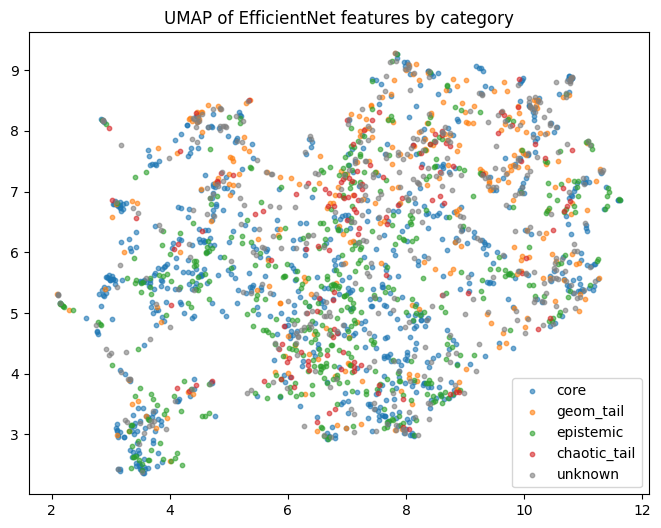

In [3]:
colors = {
    "core": "tab:blue",
    "geom_tail": "tab:orange",
    "epistemic": "tab:green",
    "chaotic_tail": "tab:red",
    "unknown": "tab:gray",
}

plt.figure(figsize=(8, 6))
for cat, color in colors.items():
    mask = df["category"] == cat
    plt.scatter(
        df.loc[mask, "umap_x"],
        df.loc[mask, "umap_y"],
        s=10,
        alpha=0.6,
        c=color,
        label=cat,
    )

plt.legend()
plt.title("UMAP of EfficientNet features by category")
plt.show()
